# Actual DendriticErrorNetwork Check

This notebook validates the actual `DendriticError-1810-lite` implementation used in `tinystories_llama_token_experiment.py`.

Important scope: the current experiment script no longer contains the full three-compartment PyraLNet-style model. The retained model is the simplified basal/apical dendritic error estimator:

$$\text{trace} \rightarrow a=W_{in}x+b_h \rightarrow h=\tanh(a) \rightarrow z=W_{out}h+b_{out}$$

with output error feedback into a hidden apical perturbation.

In [1]:
from pathlib import Path
import sys
import inspect
import numpy as np
import matplotlib.pyplot as plt

IDEA_DIR = Path('/private/zhenningshi/idea')
sys.path.insert(0, str(IDEA_DIR))

from tinystories_llama_token_experiment import (  # noqa: E402
    DendriticErrorConfig,
    DendriticErrorNetwork,
    train_dendritic_error,
    softmax,
)

np.set_printoptions(precision=5, suppress=True)

/opt/conda/envs/thinkleap/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Confirm the Imported Training Rule

The notebook uses the actual training function from the experiment file. The relevant update is:

```python
feedback = model.feedback @ output_error
nudged_hidden = tanh(basal - lambda_apical * feedback)
hidden_error_estimate = nudged_hidden - hidden
model.w_in += lr_in * outer(hidden_error_estimate, trace)
```

In [2]:
src = inspect.getsource(train_dendritic_error)
for line in src.splitlines()[18:45]:
    print(line)

        loss, acc = evaluate_dendritic_probe(model, curve_probe[0], curve_probe[1], curve_temperature)
        append_curve_row(curve_rows, curve_method, 0, loss, acc)

    for idx in range(total_steps):
        current = int(ids[idx])
        target = int(ids[idx + 1])
        trace *= cfg.trace_decay
        trace[current] += 1.0

        basal, hidden = model.hidden(trace)
        logits = model.w_out @ hidden + model.b_out
        probs = softmax(logits)
        output_error = probs
        output_error[target] -= 1.0

        feedback = model.feedback @ output_error
        nudged_hidden = np.tanh(basal - cfg.lambda_apical * feedback)
        hidden_error_estimate = np.clip(nudged_hidden - hidden, -cfg.grad_clip, cfg.grad_clip)

        out_update = np.outer(output_error, hidden)
        in_update = np.outer(hidden_error_estimate, trace)
        np.clip(out_update, -cfg.grad_clip, cfg.grad_clip, out=out_update)
        np.clip(in_update, -cfg.grad_clip, cfg.grad_clip, out=in_updat

## Utility Functions

In [4]:
def f(x):
    return np.tanh(x)

def fprime(x):
    return 1.0 - np.tanh(x) ** 2

def cosine(a, b):
    return float(np.dot(a.ravel(), b.ravel()) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-12))

def rel_error(a, b):
    return float(np.linalg.norm(a - b) / (np.linalg.norm(b) + 1e-12))

def one_step_terms(model, trace, target):
    basal, hidden = model.hidden(trace)
    logits = model.w_out @ hidden + model.b_out
    probs = softmax(logits)
    output_error = probs.copy()
    output_error[target] -= 1.0
    feedback = model.feedback @ output_error
    nudged_hidden = np.tanh(basal - model.cfg.lambda_apical * feedback)
    hidden_error_estimate = nudged_hidden - hidden
    return basal, hidden, logits, probs, output_error, feedback, hidden_error_estimate

## Build One Actual Model Step

Use compact-token-like IDs and the actual `DendriticErrorNetwork`. We use `feedback_mode='symmetric'` first so that feedback is exactly $W_{out}^T(p-y)$. In that case the finite-difference hidden signal should align with BP descent.

In [5]:
vocab_size = 17
hidden_dim = 9
seed = 123
current = 4
target = 11

cfg = DendriticErrorConfig(
    trace_decay=0.85,
    lr_in=0.02,
    lr_out=0.02,
    lambda_apical=1e-3,
    grad_clip=100.0,
    feedback_mode='symmetric',
)

model = DendriticErrorNetwork(vocab_size, hidden_dim, cfg, seed)
trace = np.zeros(vocab_size, dtype=np.float32)
trace[current] = 1.0

basal, hidden, logits, probs, output_error, feedback, hidden_error_estimate = one_step_terms(model, trace, target)
bp_hidden_error = fprime(basal) * (model.w_out.T @ output_error)
bp_descent_hidden = -bp_hidden_error

print('target:', target)
print('pred:', int(np.argmax(probs)))
print('CE:', -np.log(float(probs[target]) + 1e-12))

target: 11
pred: 11
CE: 2.588912534659517


## Actual Script Signal vs BP Descent

The script uses a one-sided perturbation:

$$\Delta h_{script}=f(a-\lambda b)-f(a).$$

For small $\lambda$:

$$\Delta h_{script}/\lambda \approx -f'(a)b.$$

With symmetric feedback $b=W_{out}^T(p-y)$, this is the BP descent direction for hidden pre-activations.

In [6]:
script_hidden_descent_estimate = hidden_error_estimate / cfg.lambda_apical

print('cos(script/lambda, BP descent hidden):', cosine(script_hidden_descent_estimate, bp_descent_hidden))
print('relerr(script/lambda, BP descent hidden):', rel_error(script_hidden_descent_estimate, bp_descent_hidden))

script_w_in_update = np.outer(hidden_error_estimate, trace)
bp_descent_w_in_update = -np.outer(bp_hidden_error, trace)

print('cos(script update/lambda, BP descent W_in update):', cosine(script_w_in_update / cfg.lambda_apical, bp_descent_w_in_update))
print('relerr(script update/lambda, BP descent W_in update):', rel_error(script_w_in_update / cfg.lambda_apical, bp_descent_w_in_update))

cos(script/lambda, BP descent hidden): 0.9999999403953552
relerr(script/lambda, BP descent hidden): 5.575723116635345e-05
cos(script update/lambda, BP descent W_in update): 0.9999999403953552
relerr(script update/lambda, BP descent W_in update): 5.575723116635345e-05


## Center Difference Using the User-Specified Definition

Now use the explicit central difference:

$$\frac{f(a+\epsilon b)-f(a-\epsilon b)}{2\epsilon}\approx f'(a)b.$$

For BP descent we compare the negative version:

$$\frac{f(a-\epsilon b)-f(a+\epsilon b)}{2\epsilon}\approx -f'(a)b.$$

In [7]:
eps_values = np.logspace(-1, -8, 8)
rows = []
for eps in eps_values:
    center_descent = (f(basal - eps * feedback) - f(basal + eps * feedback)) / (2.0 * eps)
    rows.append({
        'eps': eps,
        'hidden_rel_error': rel_error(center_descent, bp_descent_hidden),
        'hidden_cosine': cosine(center_descent, bp_descent_hidden),
    })

for row in rows:
    print(f"eps={row['eps']:.0e} rel={row['hidden_rel_error']:.3e} cos={row['hidden_cosine']:.8f}")

eps=1e-01 rel=6.602e-04 cos=0.99999995
eps=1e-02 rel=6.706e-06 cos=0.99999999
eps=1e-03 rel=1.808e-07 cos=0.99999999
eps=1e-04 rel=1.239e-07 cos=0.99999999
eps=1e-05 rel=1.234e-07 cos=0.99999999
eps=1e-06 rel=1.234e-07 cos=0.99999999
eps=1e-07 rel=1.234e-07 cos=0.99999999
eps=1e-08 rel=1.240e-07 cos=0.99999999


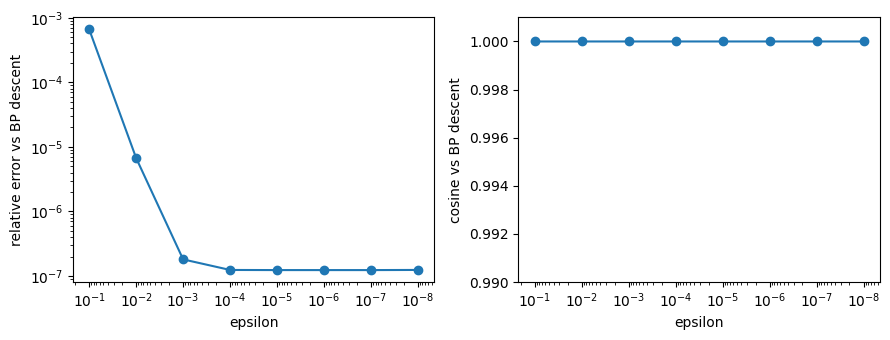

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9, 3.5))
ax[0].loglog([r['eps'] for r in rows], [r['hidden_rel_error'] for r in rows], marker='o')
ax[0].invert_xaxis()
ax[0].set_xlabel('epsilon')
ax[0].set_ylabel('relative error vs BP descent')

ax[1].semilogx([r['eps'] for r in rows], [r['hidden_cosine'] for r in rows], marker='o')
ax[1].invert_xaxis()
ax[1].set_xlabel('epsilon')
ax[1].set_ylabel('cosine vs BP descent')
ax[1].set_ylim(0.99, 1.001)
fig.tight_layout()
plt.show()

## Verify One-Step Training Calls the Same Rule

This calls the real `train_dendritic_error()` function on a two-token sequence and compares its changed `W_in` to the manual script update above.

In [9]:
trained = train_dendritic_error(
    np.array([current, target], dtype=np.int64),
    vocab_size=vocab_size,
    hidden_dim=hidden_dim,
    cfg=cfg,
    seed=seed,
    show_progress=False,
)

manual = DendriticErrorNetwork(vocab_size, hidden_dim, cfg, seed)
manual.w_in += cfg.lr_in * script_w_in_update
manual.b_h += cfg.lr_in * hidden_error_estimate

print('max |trained.w_in - manual.w_in|:', np.max(np.abs(trained.w_in - manual.w_in)))
print('max |trained.b_h - manual.b_h|:', np.max(np.abs(trained.b_h - manual.b_h)))

max |trained.w_in - manual.w_in|: 0.0
max |trained.b_h - manual.b_h|: 0.0


## Default Fixed Feedback Is Not Exact BP

The experiment default is `feedback_mode='fixed'`, which uses random feedback rather than $W_{out}^T$. In that case the finite-difference still estimates $-f'(a)b$, but $b$ is not the exact BP feedback direction.

In [10]:
fixed_cfg = DendriticErrorConfig(lambda_apical=1e-3, grad_clip=100.0, feedback_mode='fixed')
fixed_model = DendriticErrorNetwork(vocab_size, hidden_dim, fixed_cfg, seed)
basal_f, hidden_f, logits_f, probs_f, output_error_f, feedback_f, hidden_error_f = one_step_terms(fixed_model, trace, target)
bp_hidden_f = fprime(basal_f) * (fixed_model.w_out.T @ output_error_f)
local_descent_f = hidden_error_f / fixed_cfg.lambda_apical
analytic_local_f = -fprime(basal_f) * feedback_f

print('fixed feedback: local finite diff vs analytic local direction')
print('  relerr:', rel_error(local_descent_f, analytic_local_f))
print('  cosine:', cosine(local_descent_f, analytic_local_f))
print('fixed feedback: local finite diff vs exact BP descent')
print('  cosine:', cosine(local_descent_f, -bp_hidden_f))

fixed feedback: local finite diff vs analytic local direction
  relerr: 6.192019645823166e-05
  cosine: 1.0
fixed feedback: local finite diff vs exact BP descent
  cosine: -0.0760437548160553


## Interpretation

This notebook validates the actual lite implementation in `tinystories_llama_token_experiment.py`.

- The script's one-sided signal `tanh(basal - lambda * feedback) - tanh(basal)` is a scaled finite-difference estimate of `-f'(basal) * feedback`.
- The user-specified central difference recovers the same direction more symmetrically.
- It is BP-equivalent only when feedback is aligned with `W_out.T @ output_error`; with the default fixed random feedback it is a local error approximation, not exact BP.